In [1]:
import os 
import gc

import torch
from torch.optim import AdamW

import matplotlib.pyplot as plt

import numpy as np

import subprocess

from typing import cast

from datetime import datetime
from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
from src.data.types import DinoModel
from src.fine_tune.utils import get_device
from src.fine_tune.types import ModelInfo, ModelParameters, TrainingObjects

EMBED_PATH = EMBEDS_DIR/ ""
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "dino_fine_tune"

In [2]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
device = get_device()

2.12.0+cu130
13.0
True
1
Device: cuda


In [4]:
dino = cast(DinoModel, torch.hub.load( 
            "facebookresearch/dinov2",
            "dinov2_vits14"
        ))

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

for p in dino.blocks[-1].parameters():
    p.requires_grad = True

for p in dino.norm.parameters():
    p.requires_grad = True

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [5]:
%load_ext autoreload
%autoreload 0

from src.fine_tune import (
    DataLoading,
    contrastive_transform,
    test_transform,
    Trainer,
    TrainLogger,
    load_dataset_meta,
)

from src.fine_tune.losses.unsupervised_head import CombinedLoss, CategoryContLoss, PreservationLoss, VICRegLoss
from src.fine_tune.losses.types import LossCollection, WeightedLoss, LossName

git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()

In [6]:
data = load_dataset_meta(DB_PATH)

meta = data.meta

train_paths = data.train_paths
test_paths = data.test_paths

categories = data.categories
types = data.types

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

In [7]:
NOTES = [
    "Test using only contrastive loss on the model"
]

PARAMS: ModelParameters = {
    "seed": 42,
    "num_workers": 8,
    "pin_memory": device.type == "cuda",
    
    "samples_per_category": 16,
    "batch_size": len(categories) * 16, # * samples_per_category
    "epochs": 2,

    "model_dim": 384,
    "hidden_dim":  1536, # From dino documentation model_dim * mlp_factor, where mlp = 4
    "dropout": 0.0,
    "learning_rate": 1e-5,
    "weight_decay": 1e-4,
    "use_residual": False,
    
    "model_normaliser": "layer",
    "model_name": "model.pt",
}

In [8]:
MODEL_INFO: ModelInfo = {
    "timestamp": timestamp,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : PARAMS,
    "parent_models": {},
    "model_type": "dino_fine_tune"
}

In [ ]:
loader = DataLoading(root=ROOT, params=PARAMS, categories=categories, types=types)

train_loader, val_loader, mal_loader = loader.create_train_val_loaders(
    train_paths,
    train_transform=contrastive_transform,
    eval_transform=test_transform,
    train_ratio=0.95
)

test_dataset = loader.create_test_dataset(
    test_paths,
    transform=test_transform
)

test_loader = loader.create_test_loader(
    test_dataset,
    excluded_indices=np.empty(0, dtype=np.int64)
)

In [10]:
trainable_params = [p for p in dino.parameters() if p.requires_grad]

optimizer = AdamW(trainable_params, lr=PARAMS["learning_rate"], weight_decay=PARAMS["weight_decay"])

In [11]:
losses = LossCollection(
    losses=[
        WeightedLoss(
            name=LossName.CATEGORY_CONTRASTIVE,
            loss=CategoryContLoss(temperature=0.1),
            weight=1.0
        ),
        WeightedLoss(
            name=LossName.VICREG,
            loss=VICRegLoss(invar_weight=25, var_weight=25, cov_weight=1, var_target=1),
            weight=1.0
        )
    ]
)

logger = TrainLogger(project="MVTEC OOD", name="DINO Last Block Fine Tune", model_info=MODEL_INFO)

criterion = CombinedLoss(losses=losses)
criterion.collect_metrics = logger is not None

training_objs = TrainingObjects(
    model=dino,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ciaranwhelan245 (ciaranwhelan245-university-of-limerick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
trainer = Trainer(objs=training_objs, logger=logger)

results = trainer.train_model(
    epochs=PARAMS["epochs"], 
    train_loader=train_loader,
    val_loader=val_loader
)

try:
    trainer.save_results(
        results=results,
        MODEL_DIR=MODEL_DIR,
        MODEL_INFO=MODEL_INFO,
        timestamp=timestamp
    )

    test_metrics = trainer.test(
        mahalanobis_loader=mal_loader,
        test_loader=test_loader,
        types_to_id=loader.types_to_id,
        cat_to_id=loader.cat_to_id
    )
finally:
    del trainer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if results.error is not None:
    raise results.error

Training:   0%|          | 0/2 [00:00<?, ?it/s]

Output()

Best Model Saved (val_loss=116.2932) as epoch 2


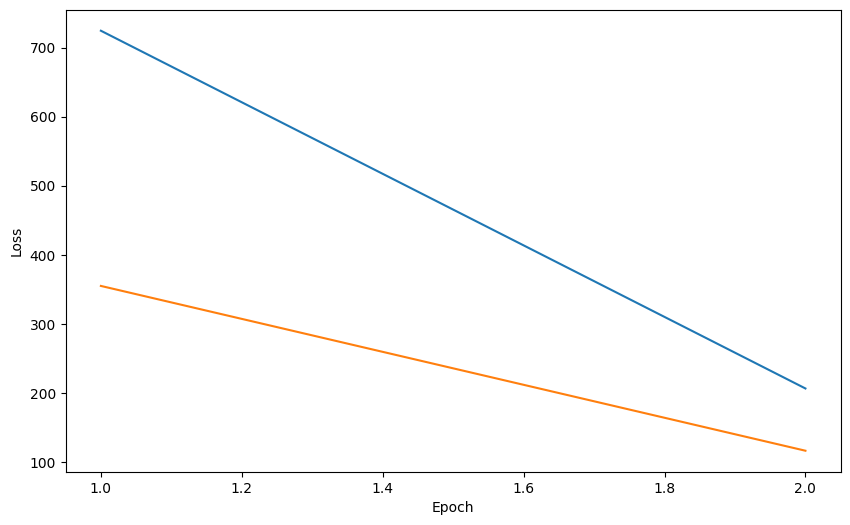

In [13]:
fig = plt.figure(figsize=(10, 6))

plt.plot(results.history["epoch"], results.history["train_loss"])
plt.plot(results.history["epoch"], results.history["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()

In [ ]:
test_metrics

test/category/silhouette                     0.527177
test/category/davies_bouldin                 0.869364
test/category/calinski_harabasz            434.822543
test/category/intra_distance                11.192500
test/category/inter_distance                 5.568521
                                              ...    
test/14/normal_defect/davies_bouldin         4.291165
test/14/normal_defect/calinski_harabasz      4.872832
test/14/normal_defect/intra_distance         9.252028
test/14/normal_defect/inter_distance         0.122911
test/14/auroc                                0.874583
Length: 170, dtype: float64

: 